# simulating the experiment

let us simulate the RAP experiment we are doing to study the effect of the parameters 

first we import the atom class to define the atom

In [9]:
import sys
sys.path.insert(0, '..')
from rap_simulation import Rubidium87, HyperfineState, Transition

In [10]:
stretch_transition = Rubidium87.list_transitions()[1]
b_field = 8e-4  #tesla
atom = Rubidium87(B_field=b_field, transition=stretch_transition)

print(atom)
print(atom.transition)
print(atom.transition_frequency)



Rubidium87(name='Rb-87 (stretch (mF=1<->mF=2))')
stretch (mF=1<->mF=2): |F=1, mF=1⟩ → |F=2, mF=2⟩
6851482610.90429


In [11]:
from rap_simulation.simulation import CompositePulse, SimulationParams
import numpy as np
parameters = SimulationParams(
        T = 2e-3,
        dt = 0.1e-6,
        omega = 2*np.pi*10e3,
        phase=np.pi,
        sweep_time = 2e-3,
        freq_span = 2*np.pi*10e3,
        freq_span_center = 0.0,
    )
rap = CompositePulse(atom, parameters)
result = rap.run(pulse="gaussian")

NameError: name 'omega' is not defined

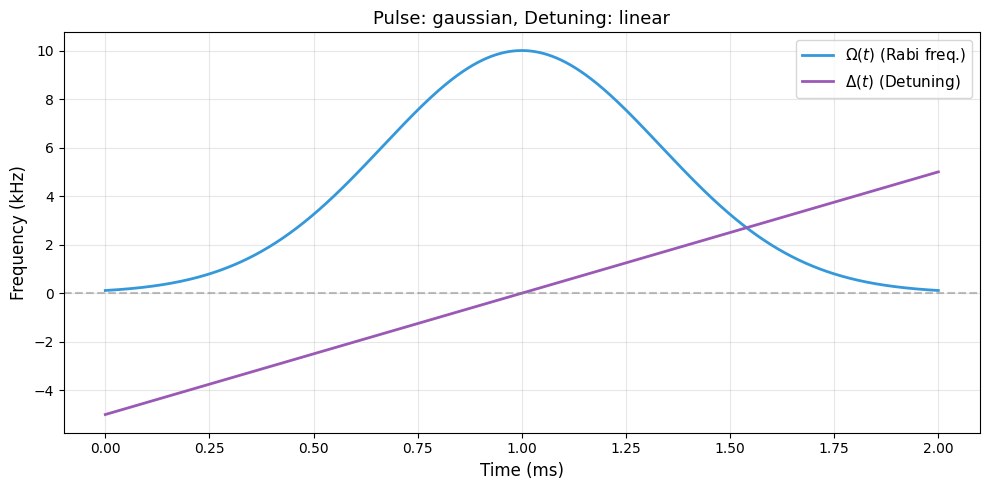

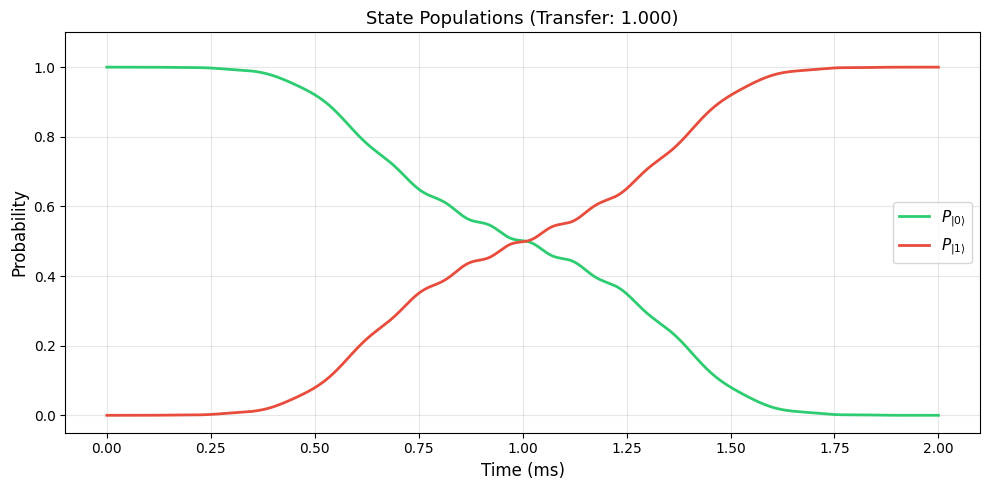

In [4]:
from rap_simulation.visualization.plots import plot_pulse_and_detuning, plot_probabilities
fig = plot_pulse_and_detuning(result, time_unit="ms", freq_unit="kHz")
fig2 = plot_probabilities(result, time_unit="ms")

In [5]:
from rap_simulation.scans import sweep_time_scan, frequency_span_scan, spectroscopy_scan

time_sweep_results = sweep_time_scan(atom = atom,
    base_params = parameters,
    t_start = 1e-6,
    t_end = 2e-3,
    n_points = 200,
    constant_freq_span = 2*np.pi*10e3,
    pulse="gaussian",
    detuning="linear"
    )


Sweep time scan: 100%|██████████| 200/200 [01:07<00:00,  2.96it/s]


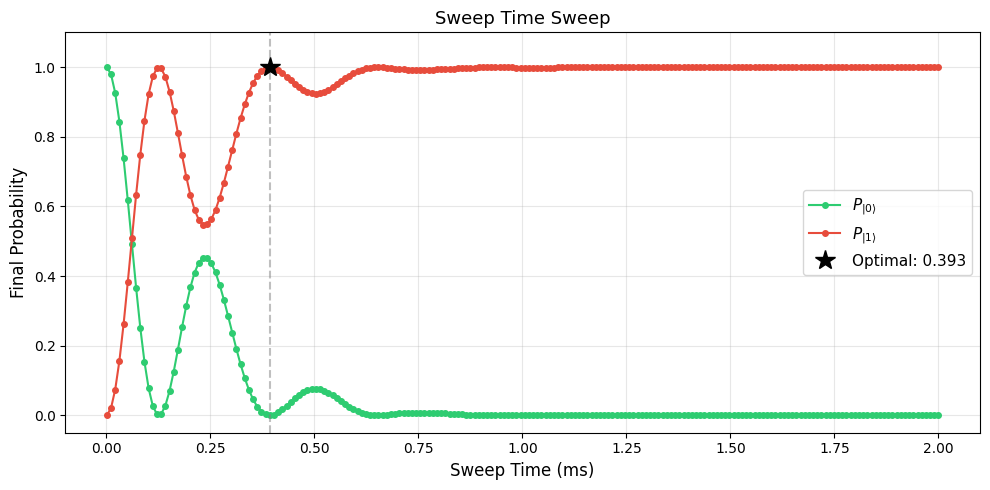

In [6]:
from rap_simulation.visualization.plots import plot_sweep_results
fig = plot_sweep_results(
    time_sweep_results.parameter_values * 1e3,  # Convert to ms
    time_sweep_results.p0_final,
    time_sweep_results.p1_final,
    parameter_name="Sweep Time",
    parameter_unit="ms",
)

Frequency span scan: 100%|██████████| 150/150 [00:23<00:00,  6.48it/s]


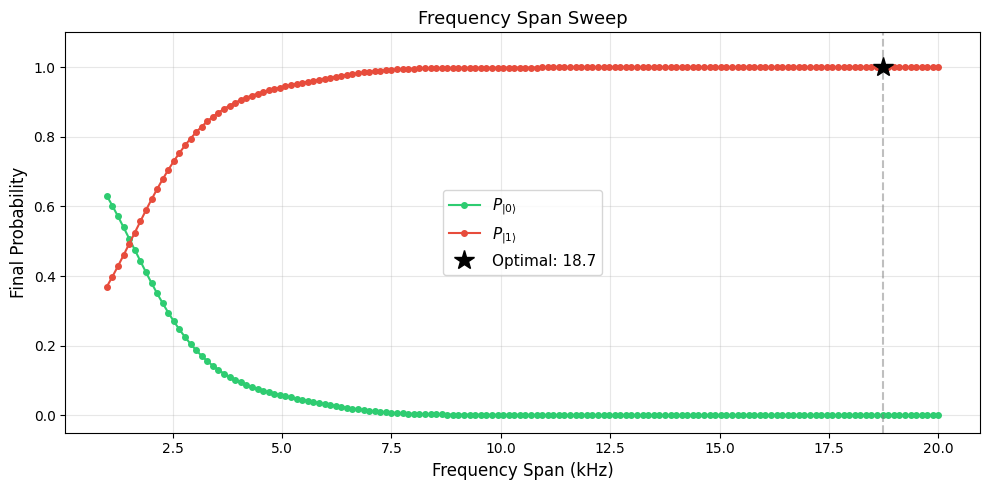

In [11]:
parameters.sweep_time = 1e-3
parameters.T = 1e-3

span_sweep_results = frequency_span_scan(atom = atom,
    base_params = parameters,
    f_start = 2*np.pi*1e3,
    f_end = 2*np.pi*20e3,
    n_points = 150,
    pulse="gaussian",
    detuning="linear"
    )

fig = plot_sweep_results(
    span_sweep_results.parameter_values/2/np.pi * 1e-3,  # Convert to kHz
    span_sweep_results.p0_final,
    span_sweep_results.p1_final,
    parameter_name="Frequency Span",
    parameter_unit="kHz",
)